In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import math

In [4]:
mnist = tf.keras.datasets.mnist

In [34]:
num_class = 10

(x_train, y_train),(x_test, y_test) = mnist.load_data()

x_train = x_train.astype("uint8") / 255
x_test = x_test.astype("uint8") / 255

y_train = tf.keras.utils.to_categorical(y_train, num_class)
y_test = tf.keras.utils.to_categorical(y_test, num_class)


In [6]:
x_train.shape

(60000, 28, 28)

In [18]:
model = tf.keras.Sequential()

model.add(tf.keras.Input(shape=(28, 28, 1)))

# Conv 2D
model.add(tf.keras.layers.Conv2D(filters=32, kernel_size=(5, 5), activation="relu"))
model.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(tf.keras.layers.Conv2D(filters=64, kernel_size=(3, 3), activation="relu"))
model.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2)))

# นำ layer สุดท้ายมาแผ่
model.add(tf.keras.layers.Flatten())

# Hidden Layer เพื่อทำพยากรณ์ผลลัพธ์
model.add(tf.keras.layers.Dense(200, activation="relu"))

# Dropout: ปิด neuron 25% ระหว่าง training เพื่อป้องกัน overfitting
model.add(tf.keras.layers.Dropout(0.25))

model.add(tf.keras.layers.Dense(100, activation="relu"))
model.add(tf.keras.layers.Dense(50, activation="relu"))
model.add(tf.keras.layers.Dense(25, activation="relu"))

# พยากรณ์ผลลัพธ์
model.add(tf.keras.layers.Dense(10, activation="softmax"))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 200)            │       320,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 366,213 (1.40 MB)

 Trainable params: 366,213 (1.40 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(optimizer='adam',
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy'])

In [20]:
model.fit(
  x_train,
  y_train,
  epochs=5 
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 13ms/step - accuracy: 0.9446 - loss: 0.1791
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.9825 - loss: 0.0598
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.9869 - loss: 0.0447
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9903 - loss: 0.0332
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9916 - loss: 0.0293


In [22]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9925 - loss: 0.0263


[0.02629353106021881, 0.9925000071525574]

In [23]:
result = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


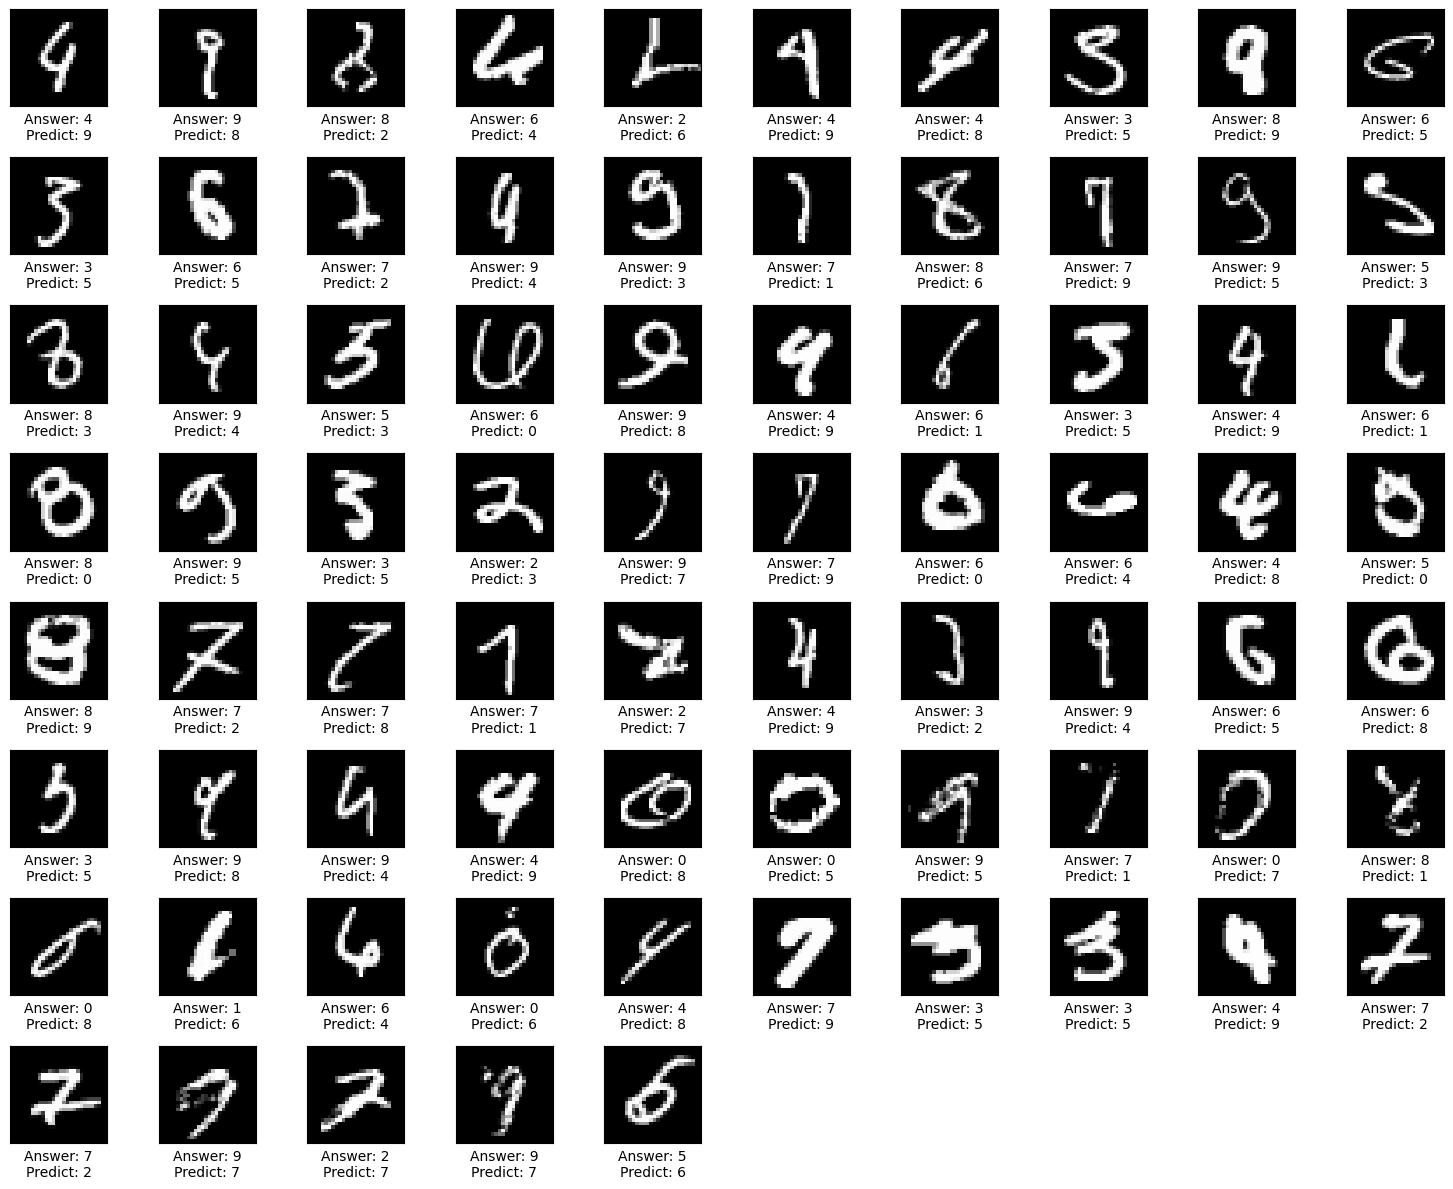

In [37]:
wrongIdx = []

# Find wrong predict indexes
for i in range(len(x_test)):
    predict = np.argmax(result[i])

    answer = np.argmax(y_test[i])

    if predict != answer:
        wrongIdx.append(i)

total_columns = 10

if len(wrongIdx) > 0:
    total_rows = math.ceil(len(wrongIdx) / total_columns)
    plt.figure(figsize=(15, total_rows * 1.5))
    for j in range(len(wrongIdx)):
        plt.subplot(total_rows, total_columns, j + 1)
        plt.imshow(x_test[wrongIdx[j]], cmap='gray')
        plt.xlabel(
            f"Answer: {np.argmax(y_test[wrongIdx[j]])}\n"
            f"Predict: {np.argmax(result[wrongIdx[j]])}"
        )
        plt.xticks([])
        plt.yticks([])
    plt.tight_layout()
    plt.show()
else:
    print("No wrong predictions found.")

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [39]:
y_pred = np.argmax(result, axis=1)
y_test_int = np.argmax(y_test, axis=1)

In [40]:
cm = confusion_matrix(y_test_int, y_pred, labels=range(10))

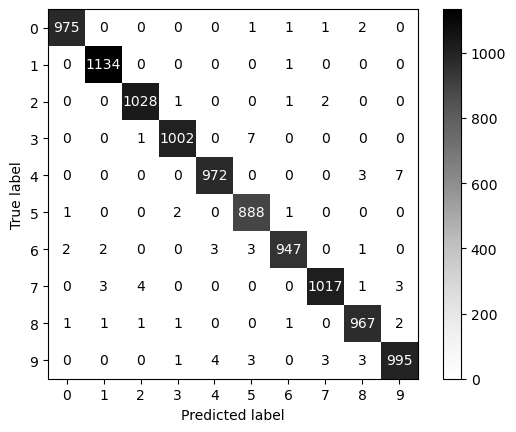

In [48]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
disp.plot(cmap=plt.cm.Grays)
plt.show()